In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("ASGN1/HousingData.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [4]:
df=df.dropna()

In [5]:
X=df.drop('MEDV',axis=1)
Y=df['MEDV']

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2)

In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [9]:
model=Sequential()
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='linear'))
model.compile(loss='mae',optimizer='adam',metrics=['mae','mse'])
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
10/10 [==============================] - 1s 4ms/step - loss: 22.3196 - mae: 22.3196 - mse: 588.0397
Epoch 2/50
10/10 [==============================] - 0s 3ms/step - loss: 21.7202 - mae: 21.7202 - mse: 563.1678
Epoch 3/50
10/10 [==============================] - 0s 2ms/step - loss: 21.0744 - mae: 21.0744 - mse: 536.9014
Epoch 4/50
10/10 [==============================] - 0s 2ms/step - loss: 20.3301 - mae: 20.3301 - mse: 507.7210
Epoch 5/50
10/10 [==============================] - 0s 2ms/step - loss: 19.4452 - mae: 19.4452 - mse: 474.3772
Epoch 6/50
10/10 [==============================] - 0s 2ms/step - loss: 18.3948 - mae: 18.3948 - mse: 436.4453
Epoch 7/50
10/10 [==============================] - 0s 2ms/step - loss: 17.1794 - mae: 17.1794 - mse: 394.9456
Epoch 8/50
10/10 [==============================] - 0s 2ms/step - loss: 15.8854 - mae: 15.8854 - mse: 351.8414
Epoch 9/50
10/10 [==============================] - 0s 2ms/step - loss: 14.6104 - mae: 14.6104 - mse: 309.8547
E

In [10]:
model.evaluate(x_test,y_test)

3/3 [==============================] - 0s 5ms/step - loss: 3.0388 - mae: 3.0388 - mse: 20.6027


[3.038811683654785, 3.038811683654785, 20.602739334106445]

3/3 [==============================] - 0s 3ms/step


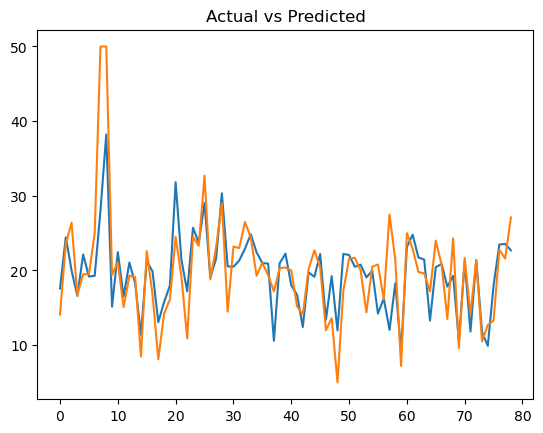

In [12]:
y_pred=np.array(model.predict(x_test)).reshape(-1,1)
y_test=np.array(y_test).reshape(-1,1)
plt.plot(y_pred,label='Predicted')
plt.plot(y_test,label='Actual')
plt.title("Actual vs Predicted")
plt.show()